In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

WORKDIR = "/Users/isabelmikheev/Desktop/Bioinformatics"
EIGENVEC = os.path.join(WORKDIR, "ursus_pca.eigenvec")
META_CSV = os.path.join(WORKDIR, "59-Ursus_workflow.csv")
OUTDIR = os.path.join(WORKDIR, "plots")
os.makedirs(OUTDIR, exist_ok=True)

def read_eigenvec(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", header=None)
    ncols = df.shape[1]
    df.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, ncols-1)]
    df["IID"] = df["IID"].astype(str)
    return df

def dedupe_meta(meta: pd.DataFrame) -> pd.DataFrame:
    # Ensure expected columns exist
    if "lat" not in meta.columns or "long" not in meta.columns:
        raise ValueError("Expected 'lat' and 'long' columns in metadata CSV.")

    # Drop rows without coordinates
    meta = meta.dropna(subset=["lat", "long"]).copy()

    # Deduplicate to 1 row per BioSample (bear)
    if "BioSample" in meta.columns:
        meta = meta.sort_values("BioSample")
        meta = meta.drop_duplicates(subset=["BioSample"], keep="first")
    else:
        # fallback: if BioSample missing, just drop exact duplicates of coords+LibraryName
        meta = meta.drop_duplicates()

    # Rename long -> lon for plotting convenience
    meta = meta.rename(columns={"long": "lon"})
    return meta

def find_best_id_col(meta: pd.DataFrame, valid_ids: set) -> str:
    best_col = None
    best_hits = -1
    for c in meta.columns:
        vals = meta[c].dropna().astype(str)
        hits = vals.isin(valid_ids).sum()
        if hits > best_hits:
            best_hits = hits
            best_col = c
    print(f"Best ID column guess: {best_col} (matches={best_hits})")
    if best_hits <= 0:
        # Print some example IDs to debug quickly
        print("Example PCA IIDs:", list(valid_ids)[:10])
        print("Example meta BioSample:", meta["BioSample"].astype(str).head(10).tolist() if "BioSample" in meta.columns else "No BioSample col")
        raise ValueError(
            "No metadata column matches PLINK eigenvec IIDs.\n"
            "This means your .fam/eigenvec sample IDs are not BioSample names.\n"
            "Next step: show the first 5 lines of ursus_pca.eigenvec and 59-Ursus.fam."
        )
    return best_col

def save_cluster_plots(df: pd.DataFrame, labels: np.ndarray, K: int):
    # PCA plot
    plt.figure()
    for cl in sorted(np.unique(labels)):
        sub = df[labels == cl]
        plt.scatter(sub["PC1"], sub["PC2"], label=f"Cluster {cl}", alpha=0.9)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title(f"PCA clusters (K={K})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"pca_clusters_K{K}.png"), dpi=200)
    plt.close()

    # Map plot
    plt.figure()
    for cl in sorted(np.unique(labels)):
        sub = df[labels == cl]
        plt.scatter(sub["lon"], sub["lat"], label=f"Cluster {cl}", alpha=0.9)
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title(f"Clusters on map coords (K={K})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"map_clusters_K{K}.png"), dpi=200)
    plt.close()

def main():
    pca = read_eigenvec(EIGENVEC)
    meta_raw = pd.read_csv(META_CSV)
    meta = dedupe_meta(meta_raw)

    valid_ids = set(pca["IID"].astype(str))
    id_col = find_best_id_col(meta, valid_ids)

    meta["IID"] = meta[id_col].astype(str)

    df = meta.merge(pca, on="IID", how="inner")
    print("Rows after merge:", len(df))
    if len(df) == 0:
        raise ValueError("Merge produced 0 rows; IDs still not matching.")

    # Save merged table
    merged_csv = os.path.join(OUTDIR, "ursus_meta_plus_pcs_deduped.csv")
    df.to_csv(merged_csv, index=False)
    print("Saved:", merged_csv)

    # Basic PCA scatter (no clustering)
    plt.figure()
    plt.scatter(df["PC1"], df["PC2"], alpha=0.9)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title("PCA: PC1 vs PC2")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "pca_PC1_PC2.png"), dpi=200)
    plt.close()
    print("Saved: pca_PC1_PC2.png")

    # Cluster experiments
    pc_cols = ["PC1", "PC2", "PC3", "PC4"]
    X = df[pc_cols].to_numpy()

    for K in [2, 3, 4, 5, 6, 7, 8]:
        km = KMeans(n_clusters=K, n_init=50, random_state=1)
        labels = km.fit_predict(X)
        save_cluster_plots(df, labels, K)
        print(f"Saved K={K} plots")

if __name__ == "__main__":
    main()

Best ID column guess: BioSample (matches=117)
Rows after merge: 117
Saved: /Users/isabelmikheev/Desktop/Bioinformatics/plots/ursus_meta_plus_pcs_deduped.csv
Saved: pca_PC1_PC2.png
Saved K=2 plots
Saved K=3 plots
Saved K=4 plots
Saved K=5 plots
Saved K=6 plots
Saved K=7 plots
Saved K=8 plots


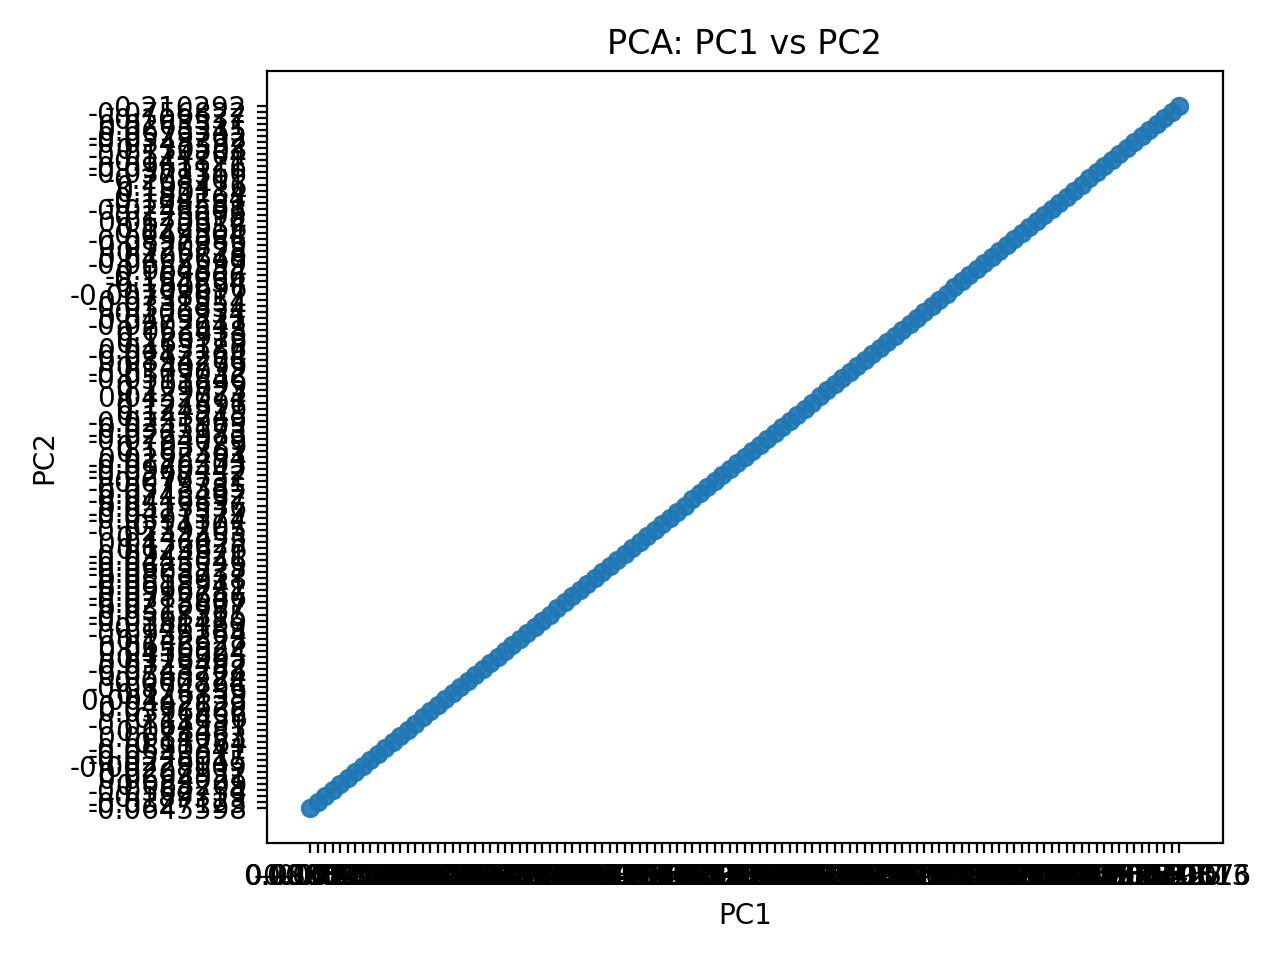

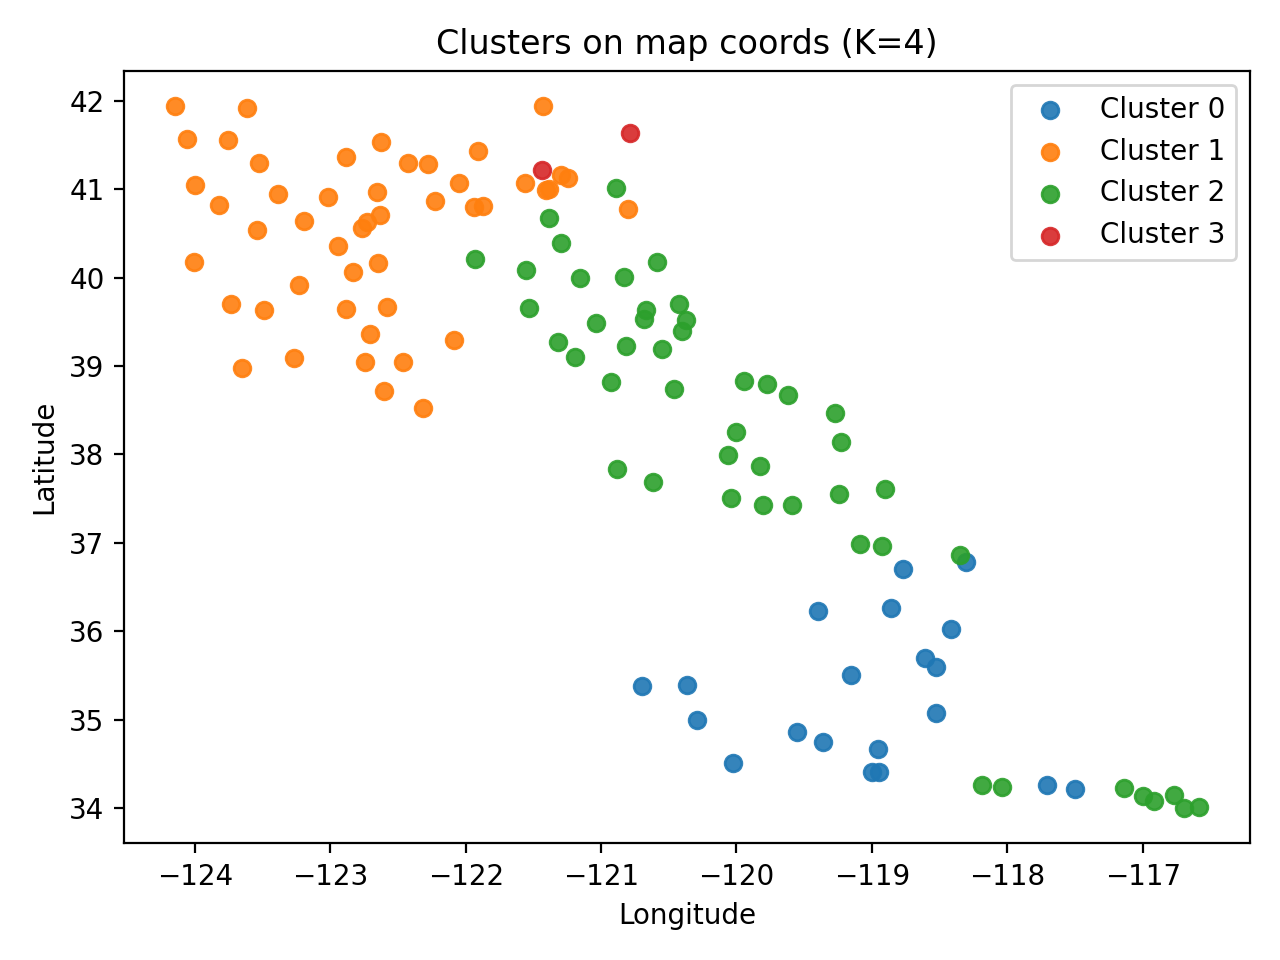

In [6]:
from IPython.display import Image, display

display(Image("/Users/isabelmikheev/Desktop/Bioinformatics/plots/pca_PC1_PC2.png"))
display(Image("/Users/isabelmikheev/Desktop/Bioinformatics/plots/map_clusters_K4.png"))  # change K if you want